In [1]:
import torch
import matplotlib.pyplot  as plt
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv(r"output_part_1.csv")

In [3]:

print(df.shape)
cols=["Item_IDs"]+[f"Feature{i}" for i in range(1,df.shape[1])]
df.columns=cols
print(df.head())

(10000, 4097)
   Item_IDs  Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
0   1117355  0.567622  2.072772       0.0       0.0  0.000000  2.598417   
1   1398321  0.000000  0.000000       0.0       0.0  0.161650  0.000000   
2   1955375  0.000000  0.000000       0.0       0.0  0.071637  1.918274   
3   1955419  0.000000  0.000000       0.0       0.0  0.000000  4.186504   
4   1398711  0.000000  0.000000       0.0       0.0  0.000000  0.000000   

   Feature7  Feature8  Feature9  ...  Feature4087  Feature4088  Feature4089  \
0  0.000000  2.013906  0.202193  ...     0.000000      0.00000     0.000000   
1  0.000000  1.079505  0.000000  ...     0.000000      0.00000     1.795291   
2  0.000000  0.000000  0.195055  ...     0.169409      0.80951     4.323596   
3  0.000000  4.273407  0.000000  ...     1.777774      0.00000     0.000000   
4  1.901946  0.583513  1.633046  ...     0.000000      0.00000     0.000000   

   Feature4090  Feature4091  Feature4092  Feature4093  Featu

In [4]:
features_cols=df.columns[1:]
df[features_cols].isnull().sum()
flag=1
null_columns=[] 
for col in features_cols:
    if df[col].isnull().any():
        flag=0
        null_columns.append(col)

print("flag ", flag)
print(null_columns)
    

flag  1
[]


      Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
2373  2.861172 -0.468470 -0.163549 -0.454155 -0.613021 -0.457226 -0.490188   
7791 -0.374945  1.629920 -0.444772  1.672826 -0.613021 -0.457226 -0.490188   
1641 -0.374945 -0.468470  0.027105 -0.454155  2.073643 -0.457226  2.140896   
1694 -0.250497  0.077785 -0.444772  0.186276 -0.613021 -0.236962 -0.490188   
7685 -0.374945 -0.468470 -0.444772 -0.454155 -0.613021 -0.457226  0.636190   

      Feature8  Feature9  Feature10  Feature11  Feature12  Feature13  \
2373 -0.490636 -0.325172  -0.607588  -0.306458   2.577183  -0.630804   
7791 -0.490636 -0.325172   0.311070   0.635895   1.729396   2.098025   
1641 -0.490636 -0.325172  -0.607588  -0.306458  -0.434182  -0.630804   
1694 -0.490636  5.186979  -0.607588  -0.306458  -0.575279   0.989611   
7685 -0.490636 -0.325172  -0.607588  -0.306458   2.103633  -0.630804   

      Feature14  Feature15  Feature16  Feature17  Feature18  Feature19  \
2373  -0.478596   1.4851

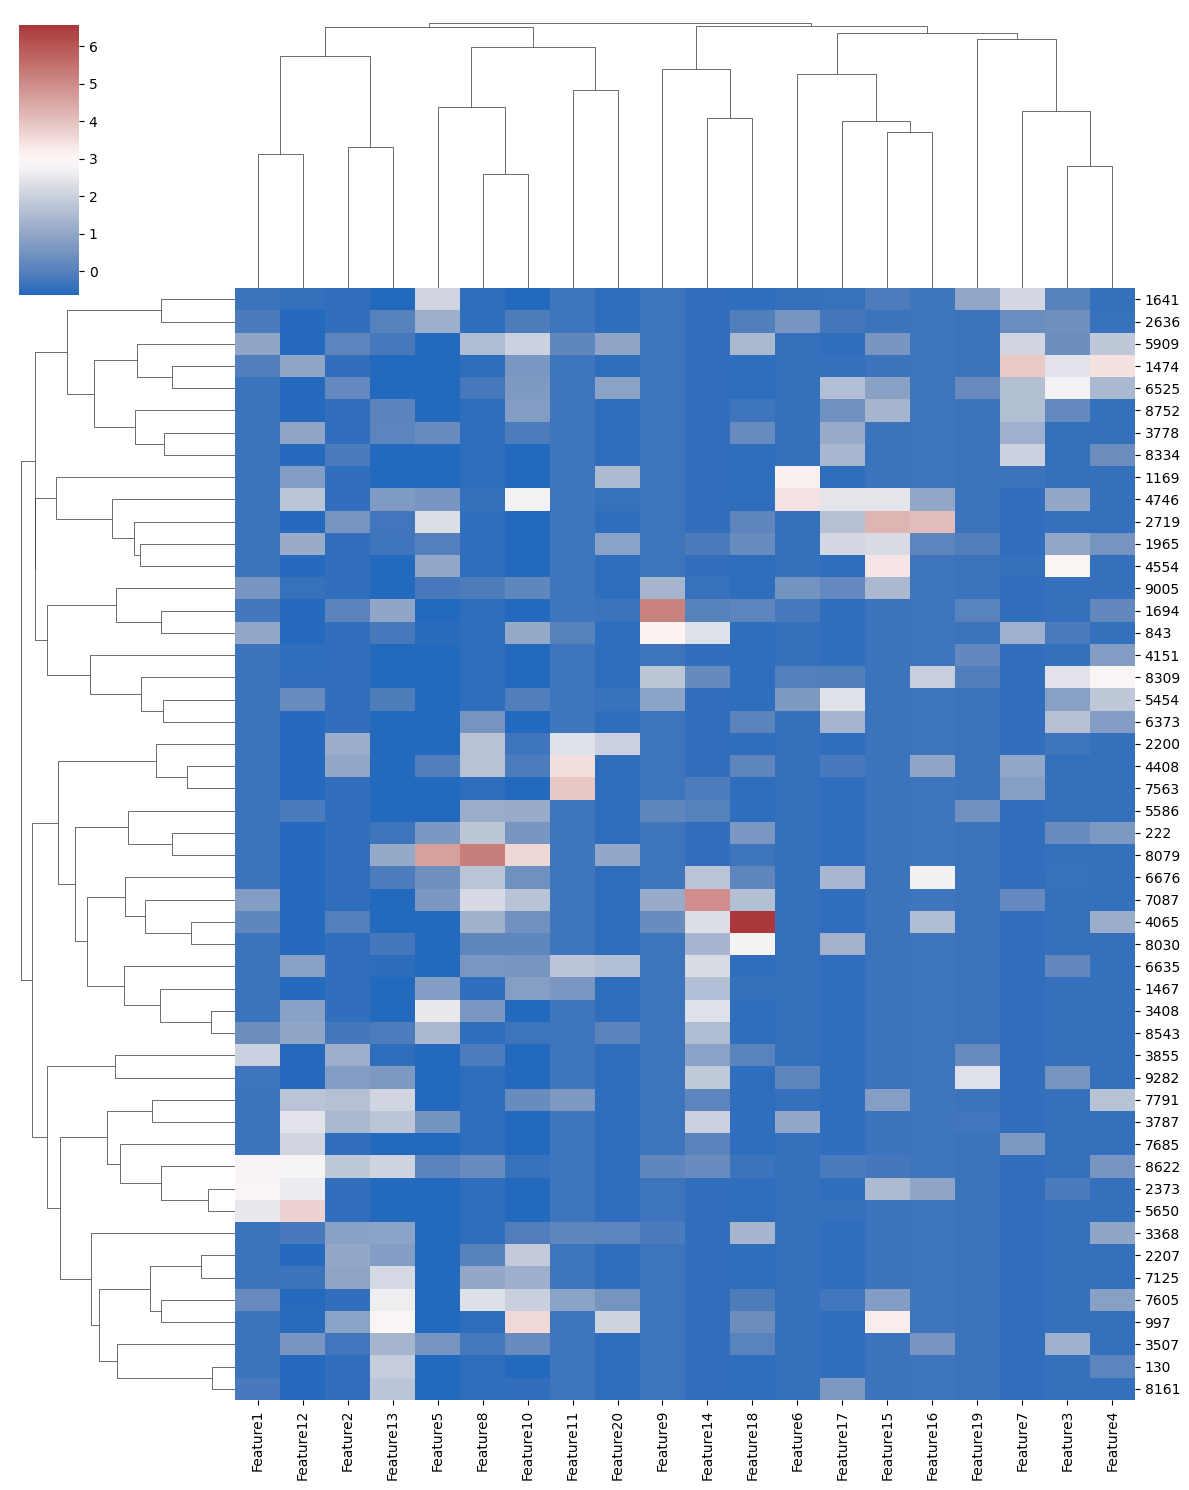

In [5]:
import seaborn as sns
#Select 20 features
#feature=df.iloc[: , 1:21]
cols=[]
for col in df.columns[1:21]:
    cols.append(col)

first_20=df[cols]  #creating a dataframe

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_feature=scaler.fit_transform(first_20)
scaled_df=pd.DataFrame(scaled_feature, index=first_20.index, columns=first_20.columns)
scaled_df=scaled_df.sample(50)
print(scaled_df.head())
#sns.clustermap(first_20.corr(), cmap="coolwarm", figsize=(12, 10))
#plt.show()
sns.clustermap(scaled_df, method="weighted", metric="cosine", cmap="vlag" , figsize=(12,15) , row_cluster=True, col_cluster=True,
               cbar_pos=(0.02,0.8,0.05,0.18))
plt.show()




Feature1       0.704108
Feature2       1.094939
Feature3       0.771606
Feature4       0.884994
Feature5       0.996907
                 ...   
Feature4092    0.646000
Feature4093    0.906556
Feature4094    0.914959
Feature4095    0.897652
Feature4096    1.411659
Length: 4096, dtype: float64
(4096,)
0.9125684548364851


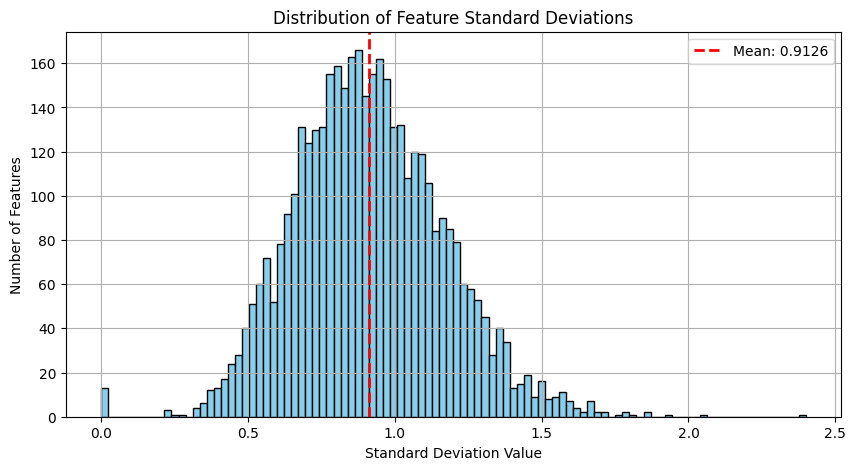

In [ ]:
#features_cols = df.columns[1:]
deviations = df[features_cols].std()
print(deviations)
print(deviations.shape)
flag1=0
for cols in deviations.index:
    if(deviations[col]==0):
        print(cols, deviations[cols])
        print (flag1)
average=deviations.mean()
print(average)
import matplotlib.pyplot as plt


# 2. Plot the distribution to see where the 'mean' falls
plt.figure(figsize=(10, 5))
deviations.hist(bins=100, color='skyblue', edgecolor='black')
plt.axvline(average, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {average:.4f}')
plt.title("Distribution of Feature Standard Deviations")
plt.xlabel("Standard Deviation Value")
plt.ylabel("Number of Features")
plt.legend()
plt.show()


        


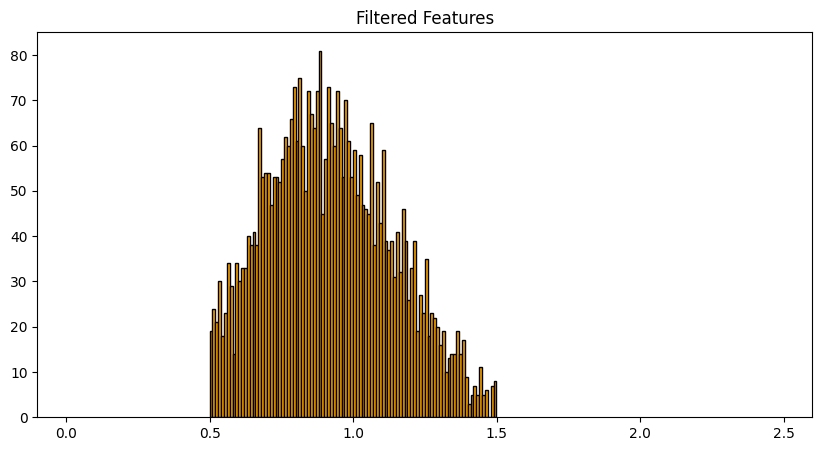

Original count: 4096
Remaining count: 3874


In [ ]:


col_drop = []
for col in deviations.index:
    if (deviations[col] < 0.5) or (deviations[col] > 1.5):
        col_drop.append(col)


drop_features = deviations.drop(index=col_drop)

# Plotting the result
plt.figure(figsize=(10, 5))
plt.hist(drop_features, bins=100, color='orange', edgecolor='black')
plt.xlim(-0.1, 2.6)
plt.title("Filtered Features")
plt.show()

print(f"Original count: {len(deviations)}")
print(f"Remaining count: {len(drop_features)}")


In [17]:
df_final=df[drop_features.index]
print(df_final)

      Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0     0.567622  2.072772       0.0  0.000000  0.000000  2.598417  0.000000   
1     0.000000  0.000000       0.0  0.000000  0.161650  0.000000  0.000000   
2     0.000000  0.000000       0.0  0.000000  0.071637  1.918274  0.000000   
3     0.000000  0.000000       0.0  0.000000  0.000000  4.186504  0.000000   
4     0.000000  0.000000       0.0  0.000000  0.000000  0.000000  1.901946   
...        ...       ...       ...       ...       ...       ...       ...   
9995  0.000000  1.165640       0.0  0.996932  0.000000  0.000000  0.000000   
9996  0.000000  3.326516       0.0  0.000000  0.000000  0.000000  0.686222   
9997  0.289124  0.728270       0.0  1.346709  0.092563  0.000000  0.000000   
9998  0.000000  0.000000       0.0  0.000000  2.239286  2.568835  1.494609   
9999  0.000000  0.000000       0.0  3.713138  0.000000  0.000000  0.000000   

      Feature9  Feature12  Feature13  ...  Feature4087  Feature